# Divar Real Estate Price Prediction Pipeline
**Course/Bootcamp:** QBC13 AI Bootcamp | Project 1  
**Target:** Housing Price Estimation (Sale Total Price & Rent Equivalent Full Credit)  
**Tasks Covered:**
1. Data loading, duplicate cleaning, and initial category inspection
2. Target definition and sale/rent labeling
3. Data cleaning, outlier handling, and year-built validation
4. Feature engineering and leakage prevention
5. Train/test split and preprocessing pipeline
6. Baseline, Random Forest, and LightGBM modeling
7. Test-set evaluation, visualizations, and feature importance


In [ ]:
# ==============================================================================
# Task 1: Data Loading and Deduplication
# ==============================================================================

import pandas as pd
import numpy as np

import warnings
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler

warnings.filterwarnings("ignore")

# 1. Find the project root by checking the current directory and its parents
file_name = "preprocessing_output_v4.parquet"
data_path = None


current_dir = Path.cwd().resolve()

for folder in [current_dir, *current_dir.parents]:
    candidate = folder / "data" / "processed" / file_name

    if candidate.exists():
        data_path = candidate
        break

if data_path is None:
    raise FileNotFoundError(
        f"Could not find '{file_name}'.\n"
        f"Current working directory: {current_dir}\n"
        "Expected project structure: data/processed/preprocessing_output_v4.parquet"
    )

# 2. Load the dataset
print(f"Loading data from: {data_path}")
df = pd.read_parquet(data_path)

print(f"Initial dataset shape: {df.shape}")

# 3. Remove an unwanted index column, if present
if "Unnamed: 0" in df.columns:
    df.drop(columns=["Unnamed: 0"], inplace=True)
    print("Dropped unwanted index column: 'Unnamed: 0'")

# 4. Remove exact duplicate rows
duplicate_count = df.duplicated().sum()
df.drop_duplicates(inplace=True)

print(f"Removed duplicate rows: {duplicate_count:,}")
print(f"Dataset shape after deduplication: {df.shape}")


# NOTE: 'cat2_slug' / 'cat3_slug' are not in this parquet -- they were already
# dropped in the upstream preprocessing step (preprocessing_output_v4), so the
# category value_counts requested by the assignment can't be run on our side.
# for col in ["cat2_slug", "cat3_slug"]:
#     if col in df.columns:
#         print(df[col].value_counts(dropna=False).head(20), "\n")

Loading data from: G:\.shortcut-targets-by-id\1u93J-JGxtx7vOpkuufdsEGMvt3u8paey\divar_analysis\preprocessing_output_v4.parquet
Initial dataset shape: (1000000, 98)
Dropped unwanted index column: 'Unnamed: 0'
Removed duplicate rows: 74
Dataset shape after deduplication: (999926, 97)


In [3]:
# ==============================================================================
# Task 2: Target Variable Definition and Sale/Rent Market Separation
# ==============================================================================

# 1. Filter dataset to include only valid standard Sale and Rent records
# In this preprocessed parquet, deal types are represented by binary flags
valid_deal_mask = (df["deal_type_sell"] == 1) | (df["deal_type_rent"] == 1)
df = df[valid_deal_mask].copy()

# 2. Create binary market indicator (1 for Sale, 0 for Rent)
df["is_sale"] = np.where(df["deal_type_sell"] == 1, 1, 0)

# 3. Construct unified target price based on transaction type:
# - Sale: price_value
# - Rent: equivalent_full_credit (full mortgage equivalent)
df["target_price"] = np.where(
    df["is_sale"] == 1, df["price_value"], df["equivalent_full_credit"]
)

# 4. Remove records with missing target price
before_target_clean = len(df)
df = df[df["target_price"].notna()].copy()
dropped_missing_target = before_target_clean - len(df)

print(f"Dataset shape after filtering sale/rent: {df.shape}")
print(f"Dropped listings with missing target price: {dropped_missing_target:,}")
print("\nDistribution across markets:")
print(f" - Sale listings: {(df['is_sale'] == 1).sum():,}")
print(f" - Rent listings: {(df['is_sale'] == 0).sum():,}")

Dataset shape after filtering sale/rent: (901571, 99)
Dropped listings with missing target price: 0

Distribution across markets:
 - Sale listings: 553,890
 - Rent listings: 347,681


In [4]:
# ==============================================================================
# Task 3: Data Cleaning, Outlier Handling, and Construction-Year Validation
# ==============================================================================

# 1. Filter strictly positive target prices
df = df[df["target_price"] > 0].copy()

# 2. Filter reasonable building size (10 to 1,500 square meters)
df = df[df["building_size"].between(10, 1500)].copy()

# 3. Handle outliers separately for Sale and Rent markets using 0.5% and 99.5% percentiles
# Separate thresholds prevent sale scale from distorting rent scale
sale_mask = df["is_sale"] == 1
rent_mask = df["is_sale"] == 0

sale_lower = df.loc[sale_mask, "target_price"].quantile(0.005)
sale_upper = df.loc[sale_mask, "target_price"].quantile(0.995)

rent_lower = df.loc[rent_mask, "target_price"].quantile(0.005)
rent_upper = df.loc[rent_mask, "target_price"].quantile(0.995)

print("Target Price Thresholds (0.5% - 99.5%):")
print(f" - Sale Market: {sale_lower:,.0f} to {sale_upper:,.0f} Tomans")
print(f" - Rent Market: {rent_lower:,.0f} to {rent_upper:,.0f} Tomans")

valid_price_mask = (sale_mask & df["target_price"].between(sale_lower, sale_upper)) | (
    rent_mask & df["target_price"].between(rent_lower, rent_upper)
)
df = df[valid_price_mask].copy()

# 4. Validate construction_year (keep realistic solar years 1340 - 1405, preserve NaN for imputer)
valid_year_mask = df["construction_year"].isna() | df["construction_year"].between(
    1340, 1405
)
df = df[valid_year_mask].copy()

print(f"\nDataset shape after cleaning & outlier removal: {df.shape}")
print(f" - Remaining Sale listings: {(df['is_sale'] == 1).sum():,}")
print(f" - Remaining Rent listings: {(df['is_sale'] == 0).sum():,}")

Target Price Thresholds (0.5% - 99.5%):
 - Sale Market: 50,000,000 to 111,111,111,111 Tomans
 - Rent Market: 4,814,811 to 15,000,000,000 Tomans

Dataset shape after cleaning & outlier removal: (870742, 99)
 - Remaining Sale listings: 531,374
 - Remaining Rent listings: 339,368


In [5]:
# ==============================================================================
# Task 4: Feature Engineering and Leakage Prevention
# ==============================================================================

# 1. Target transformation: Log-transform target price to stabilize variance
df["log_target_price"] = np.log1p(df["target_price"])

# 2. Floor ratio feature: position within building height
if "floor" in df.columns and "total_floors_count" in df.columns:
    # Replace negative or zero total_floors with NaN to prevent invalid division
    valid_total_floors = df["total_floors_count"].replace(0, np.nan)
    df["floor_ratio"] = (df["floor"] / valid_total_floors).clip(0, 1.5)
    print("Created feature: 'floor_ratio'")

# Extra added :)
if "construction_year" in df.columns:
    df["building_age"] = (1405 - df["construction_year"]).clip(lower=0)
    df.drop(columns=["construction_year"], inplace=True)


# 3. Amenity aggregation features
# Resolve exact column names: warehouse, parking, elevator, balcony
parking_col = "PreP_has_parking" if "PreP_has_parking" in df.columns else ("has_parking" if "has_parking" in df.columns else None)
warehouse_col = "PreP_has_warehouse" if "PreP_has_warehouse" in df.columns else ("has_warehouse" if "has_warehouse" in df.columns else None)
elevator_col = "PreP_has_elevator" if "PreP_has_elevator" in df.columns else ("has_elevator" if "has_elevator" in df.columns else None)
balcony_col = "PreP_has_balcony" if "PreP_has_balcony" in df.columns else ("has_balcony" if "has_balcony" in df.columns else None)

basic_cols = [c for c in [parking_col, warehouse_col, elevator_col, balcony_col] if c is not None]
df["basic_amenities"] = df[basic_cols].fillna(0).astype(int).sum(axis=1)

# Luxury amenities score (sum of available luxury flags)
luxury_candidates = [
    "PreP_has_pool", "has_pool",
    "PreP_has_sauna", "has_sauna",
    "PreP_has_jacuzzi", "has_jacuzzi",
    "has_barbecue"
]
# Select unique available luxury columns
selected_luxury_cols = []
for item in ["pool", "sauna", "jacuzzi", "barbecue"]:
    prep_c = f"PreP_has_{item}"
    raw_c = f"has_{item}"
    if prep_c in df.columns:
        selected_luxury_cols.append(prep_c)
    elif raw_c in df.columns:
        selected_luxury_cols.append(raw_c)

df["luxury_score"] = df[selected_luxury_cols].fillna(0).astype(int).sum(axis=1)

print(f"Created 'basic_amenities' using: {basic_cols}")
print(f"Created 'luxury_score' using: {selected_luxury_cols}")

# 4. Leakage Prevention: Drop any financial, rent/credit, or direct price derivatives
leakage_keywords = [
    "price", "rent", "credit", "deposit", "mortgage", "toman", "cost"
]

# Keep our defined targets, drop everything else matching leakage keywords
targets_to_preserve = {"target_price", "log_target_price"}
leakage_cols = [
    col for col in df.columns
    if any(kw in col.lower() for kw in leakage_keywords) and col not in targets_to_preserve
]

print(f"\nIdentified {len(leakage_cols)} potential leakage columns to drop:")
for c in leakage_cols:
    print(f" - {c}")

df.drop(columns=leakage_cols, inplace=True)

print(f"\nDataset shape after feature engineering & leakage removal: {df.shape}")


Created feature: 'floor_ratio'
Created 'basic_amenities' using: ['PreP_has_parking', 'PreP_has_warehouse', 'PreP_has_elevator', 'PreP_has_balcony']
Created 'luxury_score' using: ['PreP_has_pool', 'PreP_has_sauna', 'PreP_has_jacuzzi', 'PreP_has_barbecue']

Identified 17 potential leakage columns to drop:
 - rent_mode
 - rent_value
 - price_mode
 - price_value
 - credit_mode
 - credit_value
 - is_full_mortgage
 - equivalent_full_credit
 - weekend_price_ratio
 - special_day_price_ratio
 - is_rent_credit_convertible
 - log_price_value
 - log_credit_value
 - log_rent_value
 - log_equivalent_full_credit
 - deal_type_rent
 - deal_type_temporary_rent

Dataset shape after feature engineering & leakage removal: (870742, 85)


In [6]:
# ==============================================================================
# Task 5: Train/Test Split and Preprocessing Pipeline
# ==============================================================================
# 1. Separate Features (X) and Targets (y)
target_cols = ["target_price", "log_target_price"]

# Drop IDs, non-predictive texts, or metadata columns if they exist in df
id_and_text_cols = [
    col
    for col in [
        "token",
        "title",
        "description",
        "post_token",
        "chat_enabled",
        "contact_type",
        "index",
        "level_0",
    ]
    if col in df.columns
]

cols_to_drop_from_X = target_cols + id_and_text_cols
X = df.drop(columns=cols_to_drop_from_X).copy()

y_raw = df["target_price"].copy()
y_log = df["log_target_price"].copy()

print(f"X shape before split: {X.shape}")
print(f"Confirmed 'is_sale' exists in X: {'is_sale' in X.columns}")

# 2. Stratified Train / Test Split (80% Train, 20% Test) based on is_sale
X_train, X_test, y_train_log, y_test_log, y_train_raw, y_test_raw = train_test_split(
    X, y_log, y_raw, test_size=0.20, random_state=42, stratify=df["is_sale"]
)

print(f"\nTrain set size: {X_train.shape[0]:,} samples ({X_train.shape[1]} features)")
print(f"Test set size:  {X_test.shape[0]:,} samples ({X_test.shape[1]} features)")
print(f"Train sale ratio: {X_train['is_sale'].mean():.4f}")
print(f"Test sale ratio:  {X_test['is_sale'].mean():.4f}")

# 3. Detect column types for pipeline
categorical_cols = [
    c for c in X.columns if X[c].dtype == "object" or X[c].dtype.name == "category"
]
numerical_cols = [c for c in X.columns if c not in categorical_cols]

print(f"\nNumerical features count:   {len(numerical_cols)}")
print(f"Categorical features count: {len(categorical_cols)}")
if categorical_cols:
    print(f"Categorical features: {categorical_cols}")

X shape before split: (870742, 81)
Confirmed 'is_sale' exists in X: True

Train set size: 696,593 samples (81 features)
Test set size:  174,149 samples (81 features)
Train sale ratio: 0.6103
Test sale ratio:  0.6103

Numerical features count:   45
Categorical features count: 36
Categorical features: ['deed_type', 'has_balcony', 'has_elevator', 'has_warehouse', 'has_parking', 'has_water', 'has_warm_water_provider', 'has_electricity', 'has_gas', 'has_heating_system', 'has_cooling_system', 'has_restroom', 'has_security_guard', 'has_barbecue', 'building_direction', 'has_pool', 'has_jacuzzi', 'has_sauna', 'floor_material', 'PreP_has_pool', 'PreP_has_jacuzzi', 'PreP_has_sauna', 'PreP_has_balcony', 'PreP_has_elevator', 'PreP_has_parking', 'PreP_has_security_guard', 'PreP_has_barbecue', 'PreP_has_warehouse', 'PreP_has_warm_water_provider', 'PreP_has_heating_system', 'PreP_has_restroom', 'PreP_floor_material', 'PreP_building_direction', 'PreP_has_cooling_system', 'has_utilities', 'has_suana_jac

In [7]:
# ==============================================================================
# Pipeline Sanity Check & Robust Preprocessing
# ==============================================================================

# 1. Drop redundant deal_type_sell if still present
if "deal_type_sell" in X_train.columns:
    X_train = X_train.drop(columns=["deal_type_sell"])
    X_test = X_test.drop(columns=["deal_type_sell"])
    print(" Dropped redundant 'deal_type_sell'.")

print(f"Final features count in X_train: {X_train.shape[1]}")

# 2. Build Robust Preprocessor using make_column_selector
# This guarantees that strings like 'damavand' never enter the numeric imputer!
numerical_transformer = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", RobustScaler())]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, make_column_selector(dtype_include=np.number)),
        ("cat", categorical_transformer, make_column_selector(dtype_exclude=np.number)),
    ],
    remainder="drop",
)

# 3. Sanity check: Fit preprocessor on a small subset (5,000 samples)
sample_subset = X_train.sample(5000, random_state=42)
test_transformed = preprocessor.fit_transform(sample_subset)

print(" Sanity test passed successfully!")
print(f"Sample transformed shape (5000 rows): {test_transformed.shape}")

 Dropped redundant 'deal_type_sell'.
Final features count in X_train: 80
 Sanity test passed successfully!
Sample transformed shape (5000 rows): (5000, 498)


<div dir="rtl">
آماده‌سازی ستون‌ها و پری‌پروسسور
</div>

In [8]:
df.head(2)

,city_slug,description,title,land_size,building_size,deed_type,has_business_deed,floor,rooms_count,total_floors_count,...,building_age,is_rebuilt_was_missing,deed_type_was_missing,has_business_deed_was_missing,is_sale,target_price,log_target_price,floor_ratio,basic_amenities,luxury_score
1,tehran,دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nب...,۶۰ متر قلهک فول امکانات,195.0,60.0,unknown,-1,3.0,1.0,4.0,...,21.0,1,1,1,1,8.500000e+09,22.863332,0.75,3,0
2,tehran,تخلیه پایان ماه,آپارتمان ۳ خوابه ۱۳۲ متر,195.0,132.0,unknown,-1,3.0,3.0,4.0,...,4.0,0,1,1,0,1.616667e+09,21.203632,0.75,3,0


In [9]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler, TargetEncoder

In [10]:
# ==============================================================================
# Task 7: Column typing & Preprocessing Pipeline
# ==============================================================================

LOW_CARD_MAX = 20  # برای اینکه ستون‌های کتگوریکالی که زیر 20 مقدار دارن وان هات شن و اگه بیشترن جلوی نفرین ابعاد رو بگیریم!

if "deal_type_sell" in X_train.columns:
    X_train = X_train.drop(columns=["deal_type_sell"])
    X_test = X_test.drop(columns=["deal_type_sell"])

# bool-like columns (bool / nullable boolean / object with True, False, NaN) -> float 0/1 with NaN kept
# چون ستون‌هایی داریم که نوعشون آبجکت ثبت شده ولی در حقیقت بولین‌هایی با مقادیر خالی هستن :)
def is_bool_like(s: pd.Series) -> bool:
    vals = set(s.dropna().unique())
    return len(vals) > 0 and vals <= {True, False}

candidate_cols = X_train.select_dtypes(include=["bool", "boolean", "object"]).columns
bool_cols = [c for c in candidate_cols if is_bool_like(X_train[c])]

for c in bool_cols:
    X_train[c] = X_train[c].map({True: 1.0, False: 0.0})
    X_test[c] = X_test[c].map({True: 1.0, False: 0.0})

print("Bool-like columns converted to 0/1:", bool_cols)

# categorical columns
#مقادیر خالیشون با مقدار "میسینگ" پر میشه 
cat_all = X_train.select_dtypes(exclude="number").columns.tolist()
for c in cat_all:
    X_train[c] = X_train[c].astype(object).fillna("missing")
    X_test[c] = X_test[c].astype(object).fillna("missing")

num_all = X_train.select_dtypes(include="number").columns.tolist()
binary_cols = [c for c in num_all if X_train[c].dropna().nunique() <= 2]
numeric_cols = [c for c in num_all if c not in binary_cols]

cat_low_cols = [c for c in cat_all if X_train[c].nunique() <= LOW_CARD_MAX]
cat_high_cols = [c for c in cat_all if c not in cat_low_cols]

print(f"-> Numeric: {len(numeric_cols)} \n-> Binary: {len(binary_cols)} \n-> Cat (low): {cat_low_cols} \n-> Cat (high): {cat_high_cols}")


def build_preprocessor(scale: bool = False) -> ColumnTransformer:
    """scale=True for linear models (Ridge); trees don't need scaling."""
    num_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale:
        num_steps.append(("scaler", StandardScaler()))

    return ColumnTransformer(
        transformers=[
            ("num", Pipeline(num_steps), numeric_cols),
            ("bin", SimpleImputer(strategy="most_frequent"), binary_cols),
            ("cat_low", Pipeline([
                ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
                ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
            ]), cat_low_cols),
            ("cat_high", Pipeline([
                ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
                ("encoder", TargetEncoder(target_type="continuous", smooth="auto",
                                          cv=5, random_state=42)),
            ]), cat_high_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )

Bool-like columns converted to 0/1: ['has_water', 'has_electricity', 'has_gas', 'is_negotiable', 'is_transformable', 'PreP_has_pool', 'PreP_has_jacuzzi', 'PreP_has_sauna', 'PreP_has_balcony', 'PreP_has_elevator', 'PreP_has_parking', 'PreP_has_security_guard', 'PreP_has_barbecue', 'PreP_has_warehouse', 'has_utilities', 'has_suana_jacuzzi']
-> Numeric: 17 
-> Binary: 40 
-> Cat (low): ['deed_type', 'has_balcony', 'has_elevator', 'has_warehouse', 'has_parking', 'has_warm_water_provider', 'has_heating_system', 'has_cooling_system', 'has_restroom', 'has_security_guard', 'has_barbecue', 'building_direction', 'has_pool', 'has_jacuzzi', 'has_sauna', 'floor_material', 'PreP_has_warm_water_provider', 'PreP_has_heating_system', 'PreP_has_restroom', 'PreP_floor_material', 'PreP_building_direction', 'PreP_has_cooling_system'] 
-> Cat (high): ['city_slug']


<div dir="rtl">
توابع کمکی و جداسازی ولیدیشن
</div>

In [11]:
# ==============================================================================
# Task 8: Helpers & Train/Validation split (Test is NOT touched here)
# ==============================================================================
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


def make_model(regressor, scale=False):
    """Preprocessing + regressor, trained on log1p(target), predicting in the real scale."""
    return TransformedTargetRegressor(
        regressor=Pipeline([("prep", build_preprocessor(scale)), ("model", regressor)]),
        func=np.log1p,
        inverse_func=np.expm1,
    )


def evaluate(model, X, y_true):
    """Metrics in the REAL price scale (Tomans)."""
    y_pred = model.predict(X)
    mse = mean_squared_error(y_true, y_pred)
    return {
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R2_log": r2_score(np.log1p(y_true), np.log1p(y_pred)),
    }


X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train_raw, test_size=0.2, random_state=42, stratify=X_train["is_sale"]
)
print(f"Train-part: {X_tr.shape[0]:,} | Validation: {X_val.shape[0]:,}")

Train-part: 557,274 | Validation: 139,319


<div dir="rtl">
مدل پایه Ridge روی ولیدیشن
</div>

In [12]:
# ==============================================================================
# Baseline: Ridge inside TransformedTargetRegressor (log1p)
# ==============================================================================
ridge = make_model(Ridge(alpha=1.0), scale=True)
ridge.fit(X_tr, y_tr)

val_results = {"Ridge (baseline)": evaluate(ridge, X_val, y_val)}
pd.DataFrame(val_results).T

,R2,MAE,MSE,RMSE,R2_log
Ridge (baseline),0.321903,1.990495e+09,4.521320e+19,6.724076e+09,0.668834


<div dir="rtl">
رندوم فورست
</div>

In [13]:
# ==============================================================================
# Random Forest: hyperparameter selection on the VALIDATION set
# ==============================================================================

SUB_N = min(200000, len(X_tr))
X_sub = X_tr.sample(SUB_N, random_state=42)
y_sub = y_tr.loc[X_sub.index]

param_grid = ParameterGrid({
    "min_samples_leaf": [1, 3, 5],
    "max_features": [0.33, 0.6, 1.0],
    "max_depth": [None],
})

search_rows = []
for params in param_grid:
    rf = make_model(
        RandomForestRegressor(n_estimators=50, n_jobs=-1, random_state=42, **params)
        # عدد 50 برای استیمیتور عدد خیلی بزرگی نیست ولی چون صرفا برای شناسایی بهترین پارامتر ها اینجاییم
        # و باید 9 حالت مختلف رو حساب کنیم! تمرکز استیمیتور بالا رو روی ولیدیشن و ترین میذاریم
    )
    rf.fit(X_sub, y_sub)
    m = evaluate(rf, X_val, y_val)
    search_rows.append({**params, **m})
    print(params, f"-> val R2={m['R2']:.4f} | R2_log={m['R2_log']:.4f} | MAE={m['MAE']:,.0f}")

rf_search = pd.DataFrame(search_rows).sort_values("R2_log", ascending=False)
display(rf_search)

best_params = {k: rf_search.iloc[0][k] for k in ["min_samples_leaf", "max_features", "max_depth"]}
best_params["min_samples_leaf"] = int(best_params["min_samples_leaf"])
best_params["max_depth"] = None if pd.isna(best_params["max_depth"]) else int(best_params["max_depth"])
print("Best RF params:", best_params)

# Refit the best config on the whole train-part and score on validation
rf_val = make_model(
    RandomForestRegressor(n_estimators=150, n_jobs=-1, random_state=42, **best_params)
)
rf_val.fit(X_tr, y_tr)
val_results["Random Forest (tuned)"] = evaluate(rf_val, X_val, y_val)

pd.DataFrame(val_results).T

{'max_depth': None, 'max_features': 0.33, 'min_samples_leaf': 1} -> val R2=0.5229 | R2_log=0.7634 | MAE=1,419,157,211
{'max_depth': None, 'max_features': 0.33, 'min_samples_leaf': 3} -> val R2=0.5193 | R2_log=0.7680 | MAE=1,419,520,190
{'max_depth': None, 'max_features': 0.33, 'min_samples_leaf': 5} -> val R2=0.5091 | R2_log=0.7670 | MAE=1,434,358,481
{'max_depth': None, 'max_features': 0.6, 'min_samples_leaf': 1} -> val R2=0.5354 | R2_log=0.7630 | MAE=1,394,679,126
{'max_depth': None, 'max_features': 0.6, 'min_samples_leaf': 3} -> val R2=0.5354 | R2_log=0.7682 | MAE=1,387,232,651
{'max_depth': None, 'max_features': 0.6, 'min_samples_leaf': 5} -> val R2=0.5293 | R2_log=0.7687 | MAE=1,395,864,297
{'max_depth': None, 'max_features': 1.0, 'min_samples_leaf': 1} -> val R2=0.5321 | R2_log=0.7582 | MAE=1,406,827,947
{'max_depth': None, 'max_features': 1.0, 'min_samples_leaf': 3} -> val R2=0.5325 | R2_log=0.7642 | MAE=1,394,649,219
{'max_depth': None, 'max_features': 1.0, 'min_samples_leaf': 

,max_depth,max_features,min_samples_leaf,R2,MAE,MSE,RMSE,R2_log
5,None,0.60,5,0.529348,1.395864e+09,3.138150e+19,5.601919e+09,0.768699
4,None,0.60,3,0.535445,1.387233e+09,3.097500e+19,5.565519e+09,0.768222
1,None,0.33,3,0.519280,1.419520e+09,3.205281e+19,5.661520e+09,0.767964
2,None,0.33,5,0.509103,1.434358e+09,3.273137e+19,5.721134e+09,0.767021
8,None,1.00,5,0.528582,1.401124e+09,3.143254e+19,5.606473e+09,0.765136
7,None,1.00,3,0.532494,1.394649e+09,3.117173e+19,5.583165e+09,0.764215
0,None,0.33,1,0.522853,1.419157e+09,3.181453e+19,5.640437e+09,0.763376
3,None,0.60,1,0.535398,1.394679e+09,3.097812e+19,5.565799e+09,0.763006
6,None,1.00,1,0.532059,1.406828e+09,3.120074e+19,5.585763e+09,0.758169


Best RF params: {'min_samples_leaf': 5, 'max_features': 0.6, 'max_depth': None}


,R2,MAE,MSE,RMSE,R2_log
Ridge (baseline),0.321903,1.990495e+09,4.521320e+19,6.724076e+09,0.668834
Random Forest (tuned),0.554707,1.317715e+09,2.969062e+19,5.448910e+09,0.782520


<div dir="rtl">
ملاک انتخاب رو R2_log گذاشتم چون قیمت فروش و اجاره مقیاس خیلی متفاوتی دارن و از اون جایی که  R² روی مقیاس خام بیشتر تاثیر پذیره، ملک‌های گرون فروش میمونه. اگه بخوایم ملاک R2 یا MAE باشه، فقط sort_values رو باید عوض کنیم.
</div>

<div dir="rtl">
آموزش نهایی روی کل Train
</div>

In [14]:
# ==============================================================================
# Final fit on the FULL train set
# ==============================================================================
final_model = make_model(RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42, **best_params))

final_model.fit(X_train, y_train_raw)

TransformedTargetRegressor(func=<ufunc 'log1p'>, inverse_func=<ufunc 'expm1'>,
                           regressor=Pipeline(steps=[('prep',
                                                      ColumnTransformer(transformers=[('num',
                                                                                       Pipeline(steps=[('imputer',
                                                                                                        SimpleImputer(strategy='median'))]),
                                                                                       ['land_size',
                                                                                        'building_size',
                                                                                        'floor',
                                                                                        'rooms_count',
                                                                                        'total_floors_count',
                                                                                        'unit_per_floor',
                                                                                        'location_latitude',
                                                                                        'location_longitude',
                                                                                        'days_sin...
                                                                                        'PreP_has_cooling_system']),
                                                                                      ('cat_high',
                                                                                       Pipeline(steps=[('imputer',
                                                                                                        SimpleImputer(fill_value='missing',
                                                                                                                      strategy='constant')),
                                                                                                       ('encoder',
                                                                                                        TargetEncoder(random_state=42,
                                                                                                                      target_type='continuous'))]),
                                                                                       ['city_slug'])],
                                                                        verbose_feature_names_out=False)),
                                                     ('model',
                                                      RandomForestRegressor(max_features=0.6,
                                                                            min_samples_leaf=5,
                                                                            n_estimators=200,
                                                                            n_jobs=-1,
                                                                            random_state=42))]))

<div dir="rtl">
ارزیابی نهایی روی Test
</div>

In [15]:
# ==============================================================================
# Task 9: Final evaluation on the TEST set (used once)
# ==============================================================================
test_overall = evaluate(final_model, X_test, y_test_raw)
print("=== Test metrics (real scale, Tomans) ===")
print(f"R2   : {test_overall['R2']:.4f}")
print(f"MAE  : {test_overall['MAE']:,.0f}")
print(f"MSE  : {test_overall['MSE']:,.0f}")
print(f"RMSE : {test_overall['RMSE']:,.0f}")
print(f"R2 (log scale): {test_overall['R2_log']:.4f}")

# بررسی نتیجه نهایی به صورت جداگونه برای فروش و اجاره
rows = {"All": test_overall}
for name, flag in [("Sale", 1), ("Rent", 0)]:
    mask = (X_test["is_sale"] == flag).values
    rows[name] = evaluate(final_model, X_test[mask], y_test_raw[mask])
pd.DataFrame(rows).T

=== Test metrics (real scale, Tomans) ===
R2   : 0.5564
MAE  : 1,305,082,269
MSE  : 30,104,676,323,022,290,944
RMSE : 5,486,772,851
R2 (log scale): 0.7865


,R2,MAE,MSE,RMSE,R2_log
All,0.556353,1.305082e+09,3.010468e+19,5.486773e+09,0.786525
Sale,0.514721,1.970788e+09,4.894487e+19,6.996061e+09,0.653990
Rent,0.672061,2.627409e+08,6.052935e+17,7.780061e+08,0.654275


<div dir="rtl">
نمودار ها
</div>

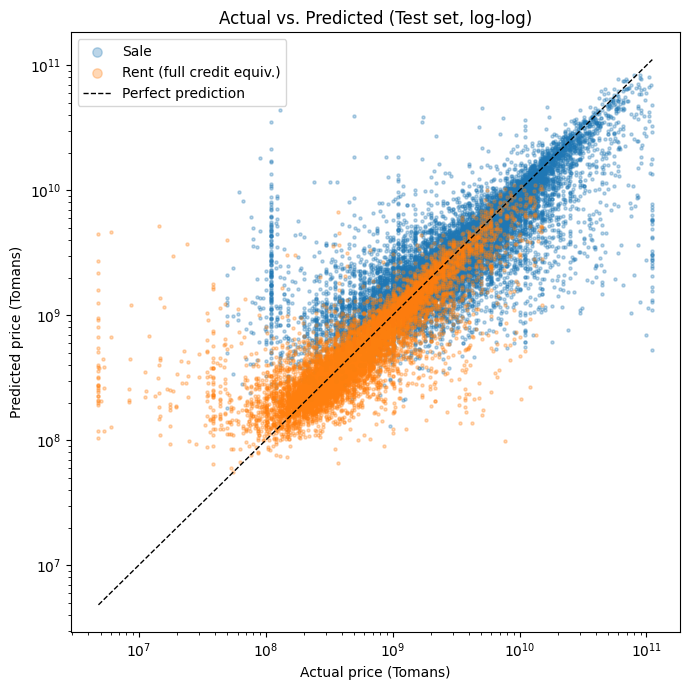

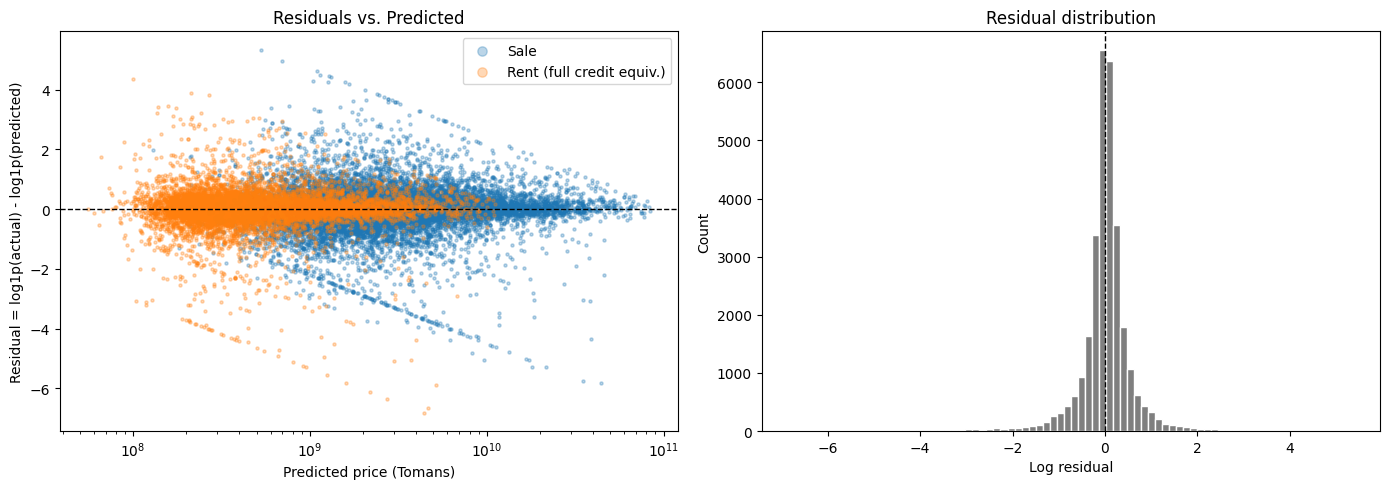

In [16]:
# ==============================================================================
# Plots: Actual vs Predicted, Residuals
# ==============================================================================
import matplotlib.pyplot as plt

y_pred_test = final_model.predict(X_test)
plot_df = pd.DataFrame({
    "actual": y_test_raw.values,
    "pred": y_pred_test,
    "is_sale": X_test["is_sale"].values,
})
plot_df = plot_df.sample(min(30000, len(plot_df)), random_state=42)
plot_df["resid_log"] = np.log1p(plot_df["actual"]) - np.log1p(plot_df["pred"])

colors = {1: "tab:blue", 0: "tab:orange"}
labels = {1: "Sale", 0: "Rent (full credit equiv.)"}

# 1) Actual vs Predicted 
fig, ax = plt.subplots(figsize=(7, 7))
for flag in (1, 0):
    d = plot_df[plot_df["is_sale"] == flag]
    ax.scatter(d["actual"], d["pred"], s=5, alpha=0.3, c=colors[flag], label=labels[flag])
lims = [plot_df[["actual", "pred"]].min().min(), plot_df[["actual", "pred"]].max().max()]
ax.plot(lims, lims, "k--", lw=1, label="Perfect prediction")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Actual price (Tomans)"); ax.set_ylabel("Predicted price (Tomans)")
ax.set_title("Actual vs. Predicted (Test set, log-log)")
ax.legend(markerscale=3)
plt.tight_layout(); plt.show()

# 2) Residual plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for flag in (1, 0):
    d = plot_df[plot_df["is_sale"] == flag]
    axes[0].scatter(d["pred"], d["resid_log"], s=5, alpha=0.3, c=colors[flag], label=labels[flag])
axes[0].axhline(0, color="k", ls="--", lw=1)
axes[0].set_xscale("log")
axes[0].set_xlabel("Predicted price (Tomans)")
axes[0].set_ylabel("Residual = log1p(actual) - log1p(predicted)")
axes[0].set_title("Residuals vs. Predicted")
axes[0].legend(markerscale=3)

axes[1].hist(plot_df["resid_log"], bins=80, color="tab:gray", edgecolor="white")
axes[1].axvline(0, color="k", ls="--", lw=1)
axes[1].set_xlabel("Log residual"); axes[1].set_ylabel("Count")
axes[1].set_title("Residual distribution")
plt.tight_layout(); plt.show()

<div dir="rtl">
اهمیت ویژگی‌ها با اسم‌های خوانا
</div>

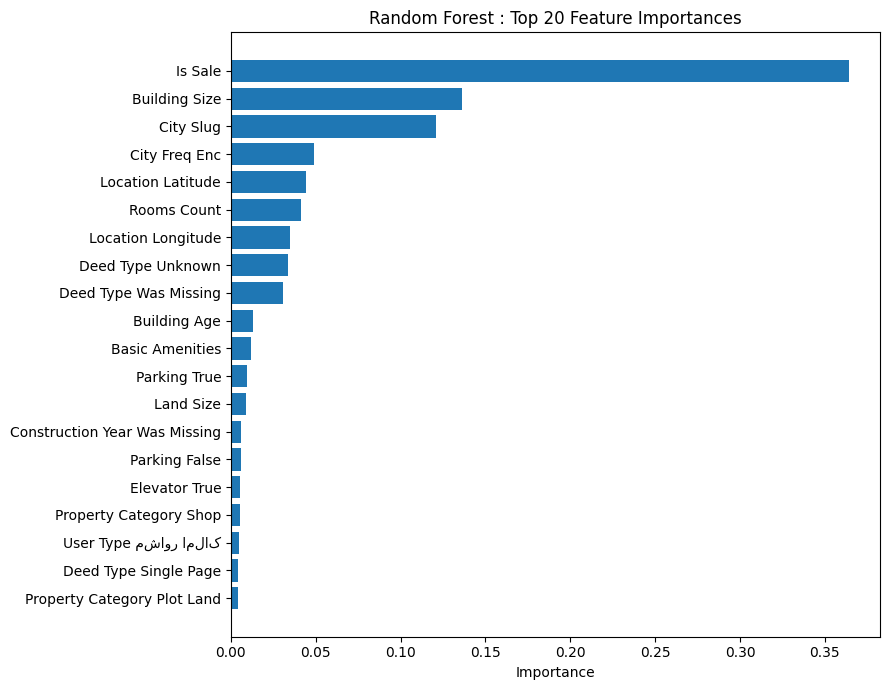

In [18]:
# ==============================================================================
# Feature Importance (top 20, clean names)
# ==============================================================================
fitted_pipe = final_model.regressor_
prep = fitted_pipe.named_steps["prep"]
rf_model = fitted_pipe.named_steps["model"]

def clean_name(name: str) -> str:
    for prefix in ("PreP_", "has_"):
        name = name.replace(prefix, "")
    return name.replace("_", " ").strip().title()

importances = pd.Series(
    rf_model.feature_importances_,
    index=[clean_name(n) for n in prep.get_feature_names_out()],
).sort_values(ascending=False)

top = importances.head(20).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top.index, top.values)
ax.set_xlabel("Importance")
ax.set_title("Random Forest : Top 20 Feature Importances")
plt.tight_layout(); plt.show()

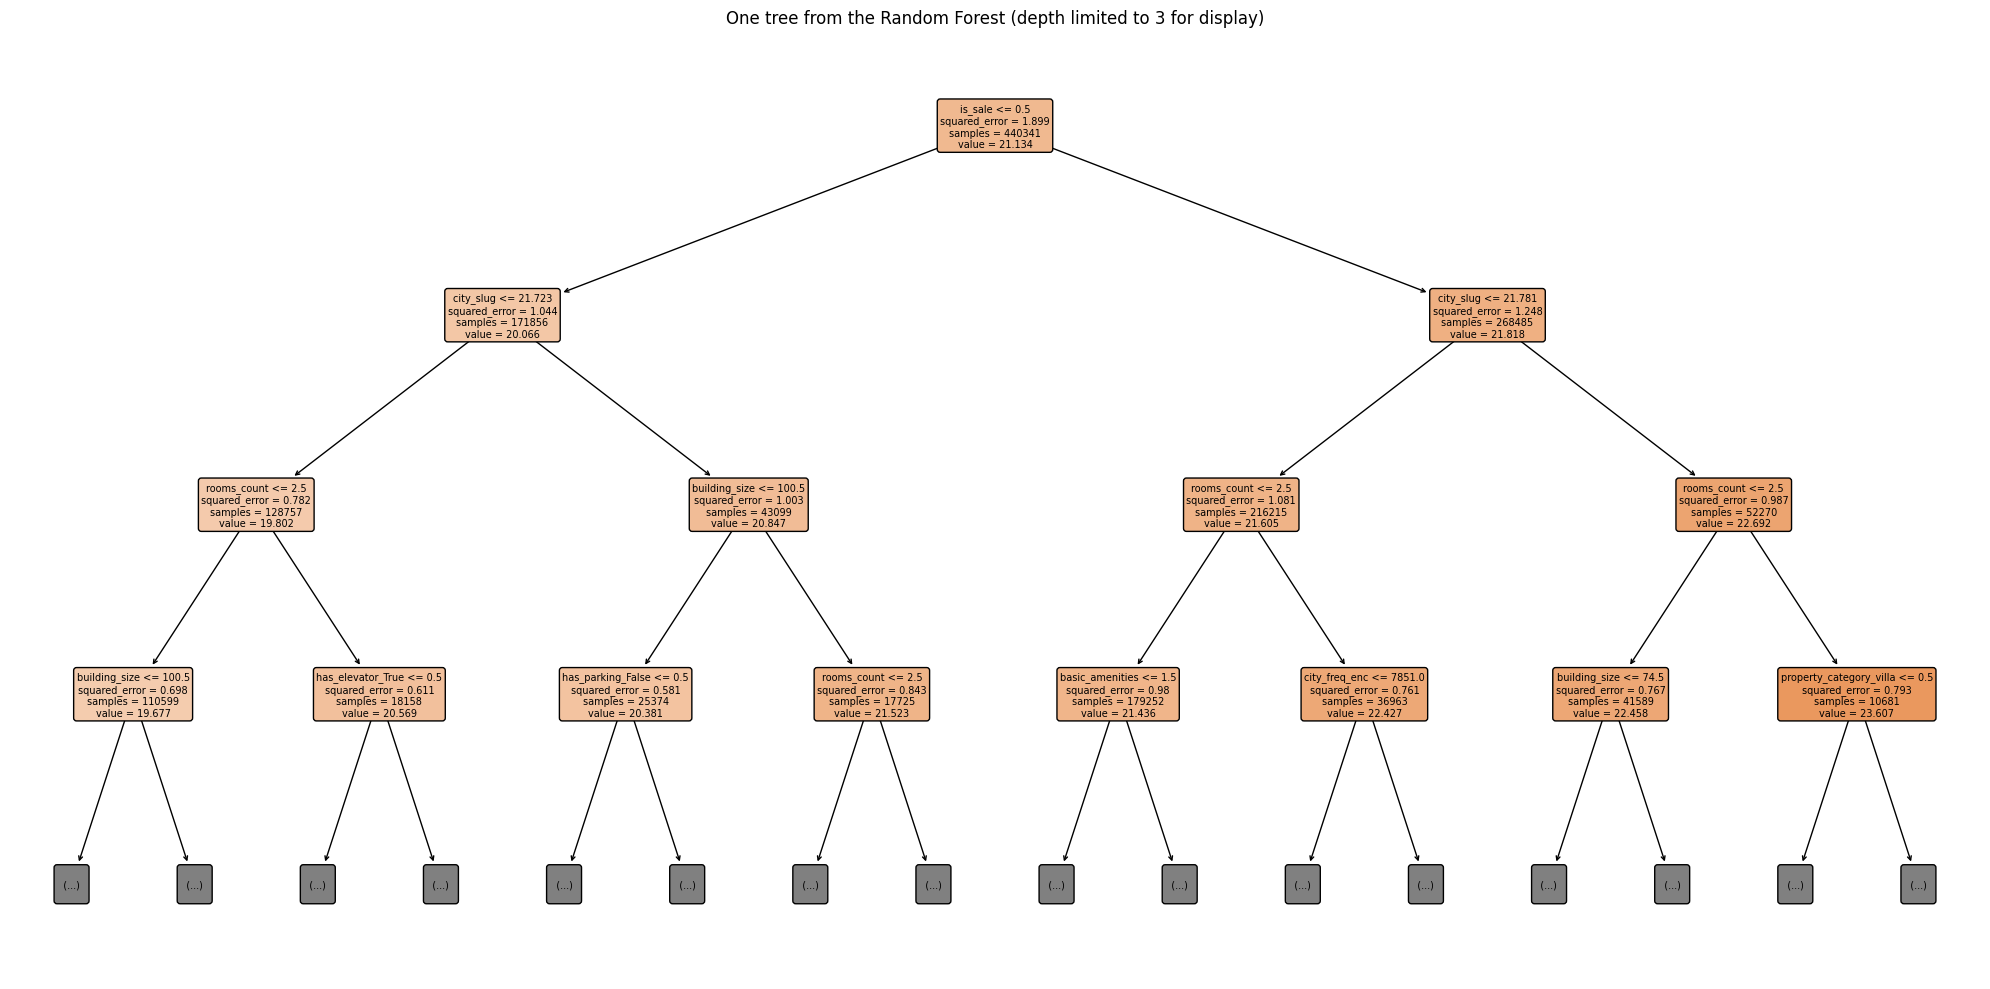

In [19]:
from sklearn.tree import plot_tree

one_tree = final_model.regressor_.named_steps["model"].estimators_[0]
feat_names = final_model.regressor_.named_steps["prep"].get_feature_names_out()

fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(one_tree, feature_names=feat_names, filled=True, rounded=True,
          max_depth=3, fontsize=7, ax=ax)  # max_depth برای تصویر لیمیت میکنه مقدارو نه برای ترین
ax.set_title("One tree from the Random Forest (depth limited to 3 for display)")
plt.tight_layout()
plt.show()